# Рекомендательная система для магазина — подготовка признаков

Задача проекта — по прошлому поведению визитора предсказывать, с какими товарами он будет взаимодействовать дальше, и выдавать Top-N рекомендаций (постановка и выбор метрик — в `01_eda.ipynb`).

На этом этапе я готовлю данные для моделей:

- разделяю историю по времени на train и целевое окно;
- считаю признаки товаров, пользователей и пар пользователь–товар;
- формирую целевую переменную;
- проверяю, что признаки не заглядывают в будущее.

Точка отсечения `cutoff = 2015-07-01` — момент, в который модель делает предсказание. Все признаки считаются только из событий до неё.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from retail_recommender.config import load_config
from retail_recommender import features as F
from retail_recommender.preprocessing.interactions import load_interactions
from retail_recommender.preprocessing.properties import load_metadata_snapshots
from retail_recommender.preprocessing.categories import load_category_paths

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 40)

cfg = load_config()
itx = load_interactions(cfg)      # processed: +ts, +is_bot, дедуп; см. build_dataset.py
meta = load_metadata_snapshots(cfg)
paths = load_category_paths(cfg)

CUTOFF = F.cutoff_ts(cfg)
WINDOW_END = F.label_window_end_ts(cfg)
STRONG = set(cfg.strong_events)   # {'addtocart', 'transaction'}
len(itx), CUTOFF.date(), STRONG

(2755641, datetime.date(2015, 7, 1), {'addtocart', 'transaction'})

## 1. Короткая проверка данных

Полная проверка качества — в `01_eda.ipynb`. Здесь только то, что важно для признаков: типы событий, отсутствие пропусков в ключах, аномально активные визиторы.

Аномально активных визиторов (больше 500 событий за весь период) исключаю как парсеров — порог выбран по результатам EDA недели 1: таких визиторов единицы, а событий у них непропорционально много (у самого активного 7757 событий). Дальше они не используются.

In [2]:
print('события:      ', len(itx))
print('период:       ', itx.ts.min().date(), '—', itx.ts.max().date())
print('типы событий: ', itx.event.value_counts().to_dict())
print('пропуски в visitorid/itemid/event:',
      int(itx[['visitorid', 'itemid', 'event']].isna().sum().sum()))
print('аномально активных визиторов:', int(itx.loc[itx.is_bot, 'visitorid'].nunique()),
      '| их доля событий:', round(itx.is_bot.mean(), 4))

события:       2755641
период:        2015-05-03 — 2015-09-18


типы событий:  {'view': 2664218, 'addtocart': 68966, 'transaction': 22457}


пропуски в visitorid/itemid/event: 0
аномально активных визиторов: 75 | их доля событий: 0.0338


## 2. Граница train / целевое окно

- **train** — всё, что произошло до `cutoff`; только из этих событий считаются все признаки;
- **целевое окно** — события после `cutoff` (до конца данных, 18 сентября); по ним видно, что визитор реально сделал дальше.

`F.pre_cutoff` отбрасывает и будущее, и аномально активных визиторов.

In [3]:
before = F.pre_cutoff(itx, CUTOFF)                       # события до cutoff, без ботов
after = itx[(~itx.is_bot) & (itx.ts >= CUTOFF) & (itx.ts < WINDOW_END)]

print(f'cutoff:            {CUTOFF.date()}')
print(f'train  (до):       {before.ts.min().date()} — {before.ts.max().date()}'
      f'   {len(before):>8} событий')
print(f'target (после):    {after.ts.min().date()} — {after.ts.max().date()}'
      f'   {len(after):>8} событий')
print()
print('до cutoff: визиторов', before.visitorid.nunique(),
      '| товаров', before.itemid.nunique(),
      '| пар (визитор, товар)', before.groupby(['visitorid', 'itemid']).ngroups)

cutoff:            2015-07-01
train  (до):       2015-05-03 — 2015-06-30    1161892 событий
target (после):    2015-07-01 — 2015-09-18    1500689 событий



до cutoff: визиторов 606714 | товаров 161570 | пар (визитор, товар) 903074


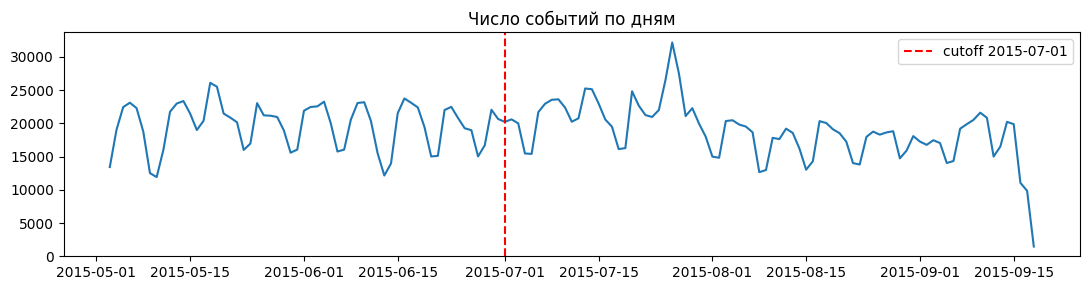

In [4]:
daily = itx[~itx.is_bot].set_index('ts').resample('D').size()
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(daily.index, daily.values)
ax.axvline(CUTOFF, color='red', ls='--', label='cutoff 2015-07-01')
ax.set_title('Число событий по дням'); ax.set_ylim(0); ax.legend()
plt.tight_layout(); plt.show(); plt.close(fig)

## 3. Признаки товаров

Всё считается только по `before`. Цен, выручки и количества в датасете нет, поэтому денежных признаков тоже нет.

Категорию беру из `item_properties` по последнему недельному срезу с датой до cutoff (`F.category_as_of`) — без заглядывания в будущее. Корневую категорию — из дерева категорий.

In [5]:
it = F.counts_by_event(before, 'itemid').add_prefix('item_n_')
it['item_n_events'] = it[['item_n_view', 'item_n_addtocart', 'item_n_transaction']].sum(axis=1)
it['item_n_users'] = before.groupby('itemid')['visitorid'].nunique()

views = it['item_n_view'].replace(0, np.nan)
it['item_cart_rate'] = (it['item_n_addtocart'] / views).fillna(0.0)
it['item_buy_rate'] = (it['item_n_transaction'] / views).fillna(0.0)
it['item_pop_share'] = it['item_n_events'] / len(before)

it['item_recency_days'] = F.days_before(CUTOFF, before.groupby('itemid')['ts'].max())
it['item_age_days'] = F.days_before(CUTOFF, before.groupby('itemid')['ts'].min())

last30 = before[before.ts >= CUTOFF - pd.Timedelta(days=30)]
prev30 = before[(before.ts < CUTOFF - pd.Timedelta(days=30))
                & (before.ts >= CUTOFF - pd.Timedelta(days=60))]
it['item_events_last_30d'] = last30.groupby('itemid').size().reindex(it.index).fillna(0)
it['item_trend_30d'] = (
    it['item_events_last_30d'] / prev30.groupby('itemid').size().reindex(it.index)
).replace([np.inf, np.nan], 0.0)

item_category = F.category_as_of(meta, CUTOFF)
root = paths.set_index('categoryid')['root']
item_features = it.reset_index()
item_features['item_categoryid'] = item_features['itemid'].map(item_category).astype('Int64')
item_features['item_root_category'] = item_features['item_categoryid'].map(root).astype('Int64')

int_cols = [c for c in item_features if c.startswith('item_n_')] + ['item_events_last_30d']
item_features[int_cols] = item_features[int_cols].astype(int)
print(item_features.shape)
item_features.head()

(161570, 15)


,itemid,item_n_view,item_n_addtocart,item_n_transaction,item_n_events,item_n_users,item_cart_rate,item_buy_rate,item_pop_share,item_recency_days,item_age_days,item_events_last_30d,item_trend_30d,item_categoryid,item_root_category
0,4,1,0,0,1,1,0.000,0.0,8.606652e-07,0.706116,0.706116,1,0.000000,1038,1532
1,6,15,0,0,15,13,0.000,0.0,1.290998e-05,15.819235,55.143598,10,2.000000,1091,1600
2,9,1,0,0,1,1,0.000,0.0,8.606652e-07,48.046360,48.046360,0,0.000000,<NA>,<NA>
3,15,8,1,0,9,7,0.125,0.0,7.745987e-06,3.857457,36.089801,6,2.000000,722,653
4,16,10,0,0,10,9,0.000,0.0,8.606652e-06,6.110538,58.301992,7,2.333333,333,1490


In [6]:
print(item_features[['item_n_events', 'item_n_users', 'item_cart_rate', 'item_buy_rate',
                     'item_recency_days', 'item_age_days', 'item_trend_30d']].describe().round(3))
print()
print('категория известна у',
      round(item_features.item_categoryid.notna().mean(), 3), 'товаров')
print('NaN по столбцам:', item_features.isna().sum()[lambda s: s > 0].to_dict())

       item_n_events  item_n_users  item_cart_rate  item_buy_rate  item_recency_days  item_age_days  item_trend_30d
count     161570.000    161570.000      161570.000     161570.000         161570.000     161570.000      161570.000
mean           7.191         5.589           0.013          0.003             19.959         38.767           0.654
std           20.075        14.582           0.078          0.032             16.842         16.771           2.030
min            1.000         1.000           0.000          0.000              0.000          0.000           0.000
25%            1.000         1.000           0.000          0.000              5.137         26.728           0.000
50%            2.000         2.000           0.000          0.000             15.128         43.139           0.000
75%            6.000         5.000           0.000          0.000             32.974         53.956           1.000
max         1212.000      1089.000           4.000          2.000       

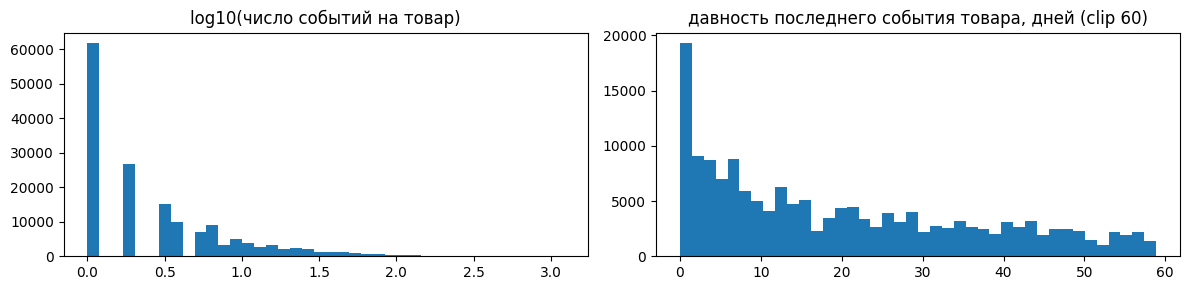

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3))
ax[0].hist(np.log10(item_features.item_n_events), bins=40)
ax[0].set_title('log10(число событий на товар)')
ax[1].hist(item_features.item_recency_days.clip(upper=60), bins=40)
ax[1].set_title('давность последнего события товара, дней (clip 60)')
plt.tight_layout(); plt.show(); plt.close(fig)

## 4. Признаки пользователей

Активность, давность, разнообразие интересов. Среднего чека нет — в данных нет цен.

In [8]:
us = F.counts_by_event(before, 'visitorid').add_prefix('user_n_')
us['user_n_events'] = us[['user_n_view', 'user_n_addtocart', 'user_n_transaction']].sum(axis=1)
us['user_n_items'] = before.groupby('visitorid')['itemid'].nunique()
us['user_is_buyer'] = (us['user_n_transaction'] > 0).astype(int)

us['user_recency_days'] = F.days_before(CUTOFF, before.groupby('visitorid')['ts'].max())
us['user_tenure_days'] = F.days_before(CUTOFF, before.groupby('visitorid')['ts'].min())
us['user_active_days'] = (before.assign(d=before.ts.dt.floor('D'))
                          .groupby('visitorid')['d'].nunique())
us['user_events_last_30d'] = (last30.groupby('visitorid').size()
                              .reindex(us.index).fillna(0).astype(int))

us['user_cart_rate'] = us['user_n_addtocart'] / us['user_n_events']
us['user_buy_rate'] = us['user_n_transaction'] / us['user_n_events']

# разнообразие интересов: сколько разных категорий у пользователя
before_cat = before[['visitorid', 'itemid']].assign(
    categoryid=before['itemid'].map(item_category))
us['user_n_categories'] = (before_cat.dropna().groupby('visitorid')['categoryid'].nunique()
                           .reindex(us.index).fillna(0).astype(int))

user_features = us.reset_index()
print(user_features.shape)
user_features.head()

(606714, 14)


,visitorid,user_n_view,user_n_addtocart,user_n_transaction,user_n_events,user_n_items,user_is_buyer,user_recency_days,user_tenure_days,user_active_days,user_events_last_30d,user_cart_rate,user_buy_rate,user_n_categories
0,7,3,0,0,3,3,0,45.818991,47.764158,2,0,0.0,0.0,2
1,8,1,0,0,1,1,0,30.998683,30.998683,1,0,0.0,0.0,0
2,12,1,0,0,1,1,0,58.340130,58.340130,1,0,0.0,0.0,1
3,13,2,0,0,2,2,0,12.803297,12.803911,1,2,0.0,0.0,1
4,14,1,0,0,1,1,0,33.362289,33.362289,1,0,0.0,0.0,1


In [9]:
print(user_features[['user_n_events', 'user_n_items', 'user_recency_days',
                     'user_tenure_days', 'user_active_days', 'user_n_categories']]
      .describe().round(3))
print()
print('доля покупателей:', round(user_features.user_is_buyer.mean(), 4))
print('NaN по столбцам:', user_features.isna().sum()[lambda s: s > 0].to_dict() or 'нет')

       user_n_events  user_n_items  user_recency_days  user_tenure_days  user_active_days  user_n_categories
count     606714.000    606714.000         606714.000        606714.000        606714.000         606714.000
mean           1.915         1.488             29.017            30.040             1.146              0.993
std            4.509         2.700             16.904            16.901             0.729              1.128
min            1.000         1.000              0.000             0.000             1.000              0.000
25%            1.000         1.000             14.129            15.135             1.000              1.000
50%            1.000         1.000             29.056            30.312             1.000              1.000
75%            2.000         1.000             43.244            44.250             1.000              1.000
max          483.000       356.000             58.875            58.875            56.000            160.000

доля покупателей: 

## 5. Признаки пар пользователь–товар

Кандидаты — пары (визитор, товар), которые встречались до cutoff. Для каждой пары: сколько и как взаимодействовали, давность, доля товара в истории пользователя, близость пользователя к категории товара.

In [10]:
ui = F.counts_by_event(before, ['visitorid', 'itemid']).add_prefix('ui_n_')
ui['ui_n_events'] = ui[['ui_n_view', 'ui_n_addtocart', 'ui_n_transaction']].sum(axis=1)
ui['ui_has_carted'] = (ui['ui_n_addtocart'] > 0).astype(int)
ui['ui_has_bought'] = (ui['ui_n_transaction'] > 0).astype(int)
ui['ui_recency_days'] = F.days_before(CUTOFF, before.groupby(['visitorid', 'itemid'])['ts'].max())
ui = ui.reset_index()

ui['ui_share_of_user'] = ui['ui_n_events'] / ui['visitorid'].map(us['user_n_events'])
ui['ui_item_pop_share'] = ui['itemid'].map(item_features.set_index('itemid')['item_pop_share'])

# близость пользователя к категории товара: доля его событий в этой категории
user_cat = (before_cat.dropna().groupby(['visitorid', 'categoryid']).size()
            .rename('n').reset_index())
ui['categoryid'] = ui['itemid'].map(item_category)
ui = ui.merge(user_cat, on=['visitorid', 'categoryid'], how='left')
ui['ui_user_cat_affinity'] = (ui['n'] / ui['visitorid'].map(us['user_n_events'])).fillna(0.0)
user_item_features = ui.drop(columns=['categoryid', 'n'])

print(user_item_features.shape,
      '| ключ уникален:', not user_item_features.duplicated(['visitorid', 'itemid']).any())
user_item_features.head()

(903074, 12) | ключ уникален: True


,visitorid,itemid,ui_n_view,ui_n_addtocart,ui_n_transaction,ui_n_events,ui_has_carted,ui_has_bought,ui_recency_days,ui_share_of_user,ui_item_pop_share,ui_user_cat_affinity
0,7,139394,1,0,0,1,0,0,47.764158,0.333333,3.098395e-05,0.666667
1,7,164941,1,0,0,1,0,0,47.762004,0.333333,9.295184e-05,0.666667
2,7,226353,1,0,0,1,0,0,45.818991,0.333333,2.581996e-06,0.333333
3,8,434230,1,0,0,1,0,0,30.998683,1.000000,8.606652e-07,0.000000
4,12,70225,1,0,0,1,0,0,58.340130,1.000000,5.163991e-06,1.000000


In [11]:
print(user_item_features[['ui_n_events', 'ui_recency_days', 'ui_share_of_user',
                          'ui_user_cat_affinity', 'ui_item_pop_share']].describe().round(4))
print()
print('пар с повторным взаимодействием (>1 события):',
      int((user_item_features.ui_n_events > 1).sum()),
      f'({(user_item_features.ui_n_events > 1).mean():.4f})')

       ui_n_events  ui_recency_days  ui_share_of_user  ui_user_cat_affinity  ui_item_pop_share
count  903074.0000      903074.0000       903074.0000           903074.0000        903074.0000
mean        1.2866          29.4712            0.6718                0.7608             0.0001
std         1.1827          16.8817            0.3769                0.3756             0.0001
min         1.0000           0.0000            0.0021                0.0000             0.0000
25%         1.0000          14.6929            0.3333                0.5000             0.0000
50%         1.0000          29.3485            1.0000                1.0000             0.0000
75%         1.0000          43.8720            1.0000                1.0000             0.0001
max       180.0000          58.8749            1.0000                1.0000             0.0010

пар с повторным взаимодействием (>1 события): 141660 (0.1569)


## 6. Целевая переменная

`target(u, i) = 1`, если пара `(u, i)` встречалась до cutoff и в целевом окне `[2015-07-01, 2015-09-18]` у этой же пары есть сильное событие (`addtocart` или `transaction`); иначе `0`.

Считаю target только для исторических пар — тех, что уже есть в `user_item_features`. Положительных пар мало: повторное сильное взаимодействие с тем же товаром в этих данных редкое. Это ещё не готовый обучающий набор — в нём нет отрицательных примеров по парам, которых до cutoff не было; кандидатов для ранжирования будем генерировать на этапе моделей.

In [12]:
strong_pairs = F.strong_events_after(itx, CUTOFF, WINDOW_END, STRONG)
target = F.build_target(user_item_features[['visitorid', 'itemid']], strong_pairs)

print('целевое окно:      2015-07-01 —', after.ts.max().date())
print('исторических пар:  ', len(target))
print('из них target = 1: ', int(target.target.sum()),
      f'({target.target.mean():.4f})')
target[target.target == 1].head()

целевое окно:      2015-07-01 — 2015-09-18
исторических пар:   903074
из них target = 1:  299 (0.0003)


,visitorid,itemid,target
7392,11523,122456,1
8042,12506,232085,1
9715,14885,375332,1
9893,15239,445061,1
11724,18024,228644,1


## 7. Итоговая таблица

Собираю всё в одну таблицу на уровне пары (визитор, товар): признаки пары + признаки пользователя + признаки товара + target. Её и будем подавать в модель классификации на следующем этапе.

In [13]:
dataset = (user_item_features
           .merge(user_features, on='visitorid', how='left')
           .merge(item_features, on='itemid', how='left')
           .merge(target, on=['visitorid', 'itemid'], how='left'))

print('итоговая таблица:', dataset.shape)
print('доля target = 1: ', round(dataset.target.mean(), 4))
print('признаков:        ', dataset.shape[1] - 3, '(без visitorid, itemid, target)')
dataset.head()

итоговая таблица: (903074, 40)
доля target = 1:  0.0003
признаков:         37 (без visitorid, itemid, target)


,visitorid,itemid,ui_n_view,ui_n_addtocart,ui_n_transaction,ui_n_events,ui_has_carted,ui_has_bought,ui_recency_days,ui_share_of_user,ui_item_pop_share,ui_user_cat_affinity,user_n_view,user_n_addtocart,user_n_transaction,user_n_events,user_n_items,user_is_buyer,user_recency_days,user_tenure_days,user_active_days,user_events_last_30d,user_cart_rate,user_buy_rate,user_n_categories,item_n_view,item_n_addtocart,item_n_transaction,item_n_events,item_n_users,item_cart_rate,item_buy_rate,item_pop_share,item_recency_days,item_age_days,item_events_last_30d,item_trend_30d,item_categoryid,item_root_category,target
0,7,139394,1,0,0,1,0,0,47.764158,0.333333,3.098395e-05,0.666667,3,0,0,3,3,0,45.818991,47.764158,2,0,0.0,0.0,2,33,3,0,36,28,0.090909,0.0,3.098395e-05,0.722826,57.558477,23,1.769231,1114,1532,0
1,7,164941,1,0,0,1,0,0,47.762004,0.333333,9.295184e-05,0.666667,3,0,0,3,3,0,45.818991,47.764158,2,0,0.0,0.0,2,108,0,0,108,64,0.000000,0.0,9.295184e-05,0.866204,58.152489,38,0.542857,1114,1532,0
2,7,226353,1,0,0,1,0,0,45.818991,0.333333,2.581996e-06,0.333333,3,0,0,3,3,0,45.818991,47.764158,2,0,0.0,0.0,2,3,0,0,3,3,0.000000,0.0,2.581996e-06,11.238056,45.818991,1,0.500000,642,250,0
3,8,434230,1,0,0,1,0,0,30.998683,1.000000,8.606652e-07,0.000000,1,0,0,1,1,0,30.998683,30.998683,1,0,0.0,0.0,0,1,0,0,1,1,0.000000,0.0,8.606652e-07,30.998683,30.998683,0,0.000000,<NA>,<NA>,0
4,12,70225,1,0,0,1,0,0,58.340130,1.000000,5.163991e-06,1.000000,1,0,0,1,1,0,58.340130,58.340130,1,0,0.0,0.0,1,6,0,0,6,4,0.000000,0.0,5.163991e-06,22.280142,58.340130,3,1.000000,1029,140,0


In [14]:
out = cfg.paths.processed_dir / 'features'
out.mkdir(parents=True, exist_ok=True)
item_features.to_parquet(out / 'item_features.parquet', index=False)
user_features.to_parquet(out / 'user_features.parquet', index=False)
user_item_features.to_parquet(out / 'user_item_features.parquet', index=False)
dataset.to_parquet(out / 'dataset.parquet', index=False)
for p in sorted(out.glob('*.parquet')):
    print(f'{p.name:26} {round(p.stat().st_size / 1e6, 1):>5} МБ')

dataset.parquet             52.9 МБ
item_features.parquet        5.4 МБ
user_features.parquet       14.7 МБ
user_item_features.parquet  16.8 МБ


## 8. Проверки на утечки и корректность

Признаки не должны зависеть от событий на/после cutoff, а агрегаты — совпадать с ручным пересчётом.

In [15]:
# 1. в таблицы попали только сущности, встречавшиеся до cutoff
assert set(item_features.itemid) <= set(before.itemid)
assert set(user_features.visitorid) <= set(before.visitorid)

# 2. давность считается от события до cutoff -> не может быть отрицательной
assert (item_features.item_recency_days >= 0).all()
assert (user_features.user_recency_days >= 0).all()

# 3. ручной пересчёт на реальном визиторе
v = int(user_features.sort_values('user_n_events', ascending=False).iloc[100].visitorid)
h = before[before.visitorid == v]
row = user_features[user_features.visitorid == v].iloc[0]
assert row.user_n_events == len(h)
assert row.user_n_items == h.itemid.nunique()
assert row.user_n_transaction == int((h.event == 'transaction').sum())
print(f'визитор {v}: {len(h)} событий до cutoff, {h.itemid.nunique()} товаров — совпало')

# 4. портим все события после cutoff -> признаки товаров не меняются
corrupt = itx.copy()
corrupt.loc[corrupt.ts >= CUTOFF, 'event'] = 'transaction'
corrupt.loc[corrupt.ts >= CUTOFF, 'itemid'] = -1
it2 = F.counts_by_event(F.pre_cutoff(corrupt, CUTOFF), 'itemid')
it0 = F.counts_by_event(before, 'itemid')
pd.testing.assert_frame_equal(it0, it2)
print('порча событий после cutoff не влияет на признаки до cutoff: OK')

визитор 253410: 130 событий до cutoff, 84 товаров — совпало


порча событий после cutoff не влияет на признаки до cutoff: OK


## Выводы

- История разделена по времени: `cutoff = 2015-07-01`, признаки — только из событий до этой даты, целевое окно — после.
- Готовы три таблицы признаков: товары (`itemid`), пользователи (`visitorid`), пары (`visitorid`, `itemid`) — популярность, конверсии, свежесть, динамика, разнообразие интересов, история пары.
- Целевая переменная — повторное сильное взаимодействие пары в целевом окне; положительных примеров мало, это надо учитывать при обучении.
- Проверки показывают, что признаки не используют будущие события.
- Следующий этап — рекомендательные модели: от популярности к коллаборативной фильтрации и классификации пар пользователь–товар.